## Burst Calculation Tutorial

This notebook demonstrates the burst identification calculation for one candidate time, at one grid using the $\beta$ statistic. The calculation done here corresponds to the example in Figure 2 in DeSalvio et al., JGR 2026.

In [1]:
# Import libraries
import numpy as np
from obspy import UTCDateTime
import scipy
import matplotlib.pyplot as plt
from pyproj import Proj

In [2]:
# Defining functions
def triggering_calculation(iwin,candidate_time,grid_seismicity,B95=np.nan):
# This function calculates beta_0 and beta_95 for the given time window (defined by iwin and window variable)
# and grid point (grid seismicity is EQ catalog, above Mc for the grid)
    # First let's extract seismicity in the time window of interest
    time_mask = np.where((grid_seismicity[:,0] > candidate_time) & (grid_seismicity[:,0] < candidate_time+windows[iwin]*60*60))[0]
    grid_qtm_mags_iwin = grid_seismicity[time_mask,1]
    Na = len(grid_qtm_mags_iwin) # Number of EQs in the time period of interest

    # Compute number of earthquakes in the background time frame
    Nback = np.sum((grid_seismicity[:,0] > (candidate_time-((rwindow_half-1)*60*60))) & (grid_seismicity[:,0] < candidate_time+(rwindow_half*60*60)))
    # We require 10 background events to do the burst calculation
    if Nback >= minimum_background:
        rand_dates = -rwindow_half + rwindow*np.random.rand(rtimes) # Generate the random times for resampling, draws from Uniform (0,1)
        random_Na = random_Na_trials(candidate_time,iwin,rand_dates,rtimes,grid_seismicity) # Generate the samples of Na
        # Use the random samples to get E[Na] and SD[Na]
        E_Na = np.mean(random_Na)
        SD_Na = np.std(random_Na,ddof=2)
        B0 = (Na - E_Na) / SD_Na # Calculate the value of beta_0
        if np.isnan(B95)==True:
            # Calculate 95% Significance Level if we don't already have it
            # Step 1 - convert the samples of Na into samples of beta
            random_beta = (random_Na - E_Na) / SD_Na
            # Fit an empirical pdf to the beta distribution:
            kde = scipy.stats.gaussian_kde(random_beta,bw_method=1.5)
            # Find the 95% significance level
            B95 = scipy.optimize.minimize(icdf,3,kde,tol=0.0001).x[0] # 3 is an initial guess
        else:
            return B0
    else:
        B0 = np.nan
        B95 = np.nan
        kde = np.nan
    return B0, B95, kde
    
def random_Na_trials(candidate_time,iwin,rand_dates,rtimes,grid_seismicity): # Create the distribution of Na
    random_Na = np.ones((rtimes))*np.nan
    for iday in range(rtimes): # Loop through the random times
        ievttime = candidate_time + rand_dates[iday]*24*60*60 # Find the random candidate time
        #Count the number of EQs in that time window
        random_Na[iday] = np.sum((grid_seismicity[:,0] > ievttime) & (grid_seismicity[:,0] < ievttime+windows[iwin]*60*60)) 
    return random_Na

def icdf(x,pdf):
    cdf_x = pdf.integrate_box_1d(-np.inf,x)
    return np.abs(cdf_x - 0.95)

def hourly_seismicity_rate(grid_seismicity,starttime,endtime):
    dt = 3600
    Seis_Rate = np.ones((int((endtime-starttime)/dt),2))*np.nan
    Seis_Rate[:,0] = np.arange(starttime,endtime,dt)-dt
    for ihr in range(len(Seis_Rate[:,0])):
        tmask = (grid_seismicity[:,0] >= Seis_Rate[ihr,0]) & (grid_seismicity[:,0] <= Seis_Rate[ihr,0] + dt);
        Seis_Rate[ihr,1] = np.sum(tmask);
    return Seis_Rate

def plot_stems(ax, times, mags, color, markersize=3, linewidth=0.5):
    for t, m in zip(times, mags):
        ax.plot([t, t], [0, m], color=color, linewidth=linewidth)
    ax.plot(times, mags, marker='o', color=color, 
            markersize=markersize, linestyle='None')

In the next cell I define some calculation parameters and load in data.

In [3]:
# Triggering Calculation Parameters
windows = np.array([24]) # Time windows in which we will look for triggered seismicity (in hrs)
radius = 10 # Half the size of the grid points used in DeSalvio et al 2026 (in km)
minimum_background = 10 # Minimum number of earthquakes required to do the calculation in the background time frame

# Random Sampling Parameters
rtimes = 10000 # Number of random trials for sampling
rwindow = 61 # Full time window to sample (30 days before and after the candidate event)
rwindow_half = 31 # Half that time window

# Leaving 30 days open on either side of the catalog for the background period
starttime = UTCDateTime('2008-02-01').timestamp
endtime = UTCDateTime('2017-12-01').timestamp

# Load the QTM Catalog
trig_path = './' # The catalog is in the same directory
catalog = np.loadtxt(trig_path+'qtm_final_12dev.hypo.txt',skiprows=1)
cat_mags = catalog[:,10]
cat_locs = catalog[:,7:10] # Latitude, Longitude, Depth
cat_times = np.ones(len(cat_mags))*np.nan

# Here I convert the times from the original format into a UTCDateTime timestamp format. 
for i in range(len(cat_mags)):
    if catalog[i,4] == 60: # If minutes = 60, make minutes = 0 and plus 1 hour
        catalog[i,4] = 0
        catalog[i,3] += 1
        
    if catalog[i,5] == 60:  # If seconds = 60, make seconds = 0 and plus 1 minute
        catalog[i,5] = 0
        catalog[i,4] += 1
    cat_times[i] = UTCDateTime(int(catalog[i,0]),int(catalog[i,1]),int(catalog[i,2]),int(catalog[i,3]),int(catalog[i,4]),catalog[i,5]).timestamp

# Here, convert to a cartesian coordinate system to make it easier to find earthquakes in the 20km square grids
# Reference origin is the median lat/lon of the catalog
ref_lat = np.median(cat_locs[:,0])
ref_lon = np.median(cat_locs[:,1])

# Azimuthal Equidistant projection centered on reference point
proj = Proj(proj='aeqd', lat_0=ref_lat, lon_0=ref_lon, datum='WGS84', units='km')

# Project catalog locations to local XY (East, North)
cat_east, cat_north = proj(cat_locs[:,1], cat_locs[:,0])  

cat_xy = np.column_stack([cat_north, cat_east])
# Define the grid point in which we will look for triggered seismicity and its Mc value
# This is taken as the example from Fig. 2 in DeSalvio et al 2026
grid_loc = np.array([33.452279789034380,-1.163205398502622e+02])
grid_xy = np.flip(proj(grid_loc[1], grid_loc[0]))

grid_mc = -0.1 #computed as the larger of a goodness of fit or Max curvature estimate

# Get the seismicity in the grid of interest
grid_mask = ((cat_mags>=grid_mc) & (cat_xy[:,1] <= (grid_xy[1] + radius)) & (cat_xy[:,1] >= (grid_xy[1] - radius)) & (cat_xy[:,0] <= (grid_xy[0] + radius)) & (cat_xy[:,0] >= (grid_xy[0] - radius)))
grid_seismicity = np.ones((np.sum(grid_mask),5))*np.nan
grid_seismicity[:,2:5] = cat_locs[grid_mask]
grid_seismicity[:,1] = cat_mags[grid_mask]
grid_seismicity[:,0] = cat_times[grid_mask]

# Compute the hourly seismicity rate
hourly_rates = hourly_seismicity_rate(grid_seismicity,starttime,endtime)    
candidate_times = hourly_rates[hourly_rates[:,1]>=3,0]

Now the significance calculation:

In [4]:
icand = 83 # selecting example from figure 2
# Do the burst calculation in the first 24 hour window
Beta_0,Beta_95,Beta_kde = triggering_calculation(0,candidate_times[icand],grid_seismicity)
print('Beta:',Beta_0)
print('95% Significance Threshold:',Beta_95)
beta_list = [Beta_0] #for plotting
if Beta_0 > Beta_95:
    print('Statistically Significant: Burst Identified')
    print('Contining the evaluation to potentially extend the burst:')
    next_day = 0
    while Beta_0 > Beta_95:
        next_day += 1
        Beta_0 = triggering_calculation(0,candidate_times[icand]+(next_day*86400),grid_seismicity,Beta_95)
        beta_list.append(Beta_0)
        if Beta_0 > Beta_95:
            print('Day',next_day+1,'also significant, Beta:',Beta_0)
        else:
            print('Day',next_day+1,'not significant, Beta:',Beta_0)
            print("Burst lasts for",next_day,'24-hour periods')

Beta: 5.55076185636
95% Significance Threshold: 3.11996545176
Statistically Significant: Burst Identified
Contining the evaluation to potentially extend the burst:
Day 2 also significant, Beta: 3.48605189071
Day 3 not significant, Beta: 1.31965488835
Burst lasts for 2 24-hour periods


In [5]:
# Preparing information for plotting
time_mask = np.where((grid_seismicity[:,0] > candidate_times[icand]-24*3*60*60) & (grid_seismicity[:,0] < candidate_times[icand]+windows[0]*3*60*60))[0]
grid_qtm_mags_iwin = grid_seismicity[time_mask,1]
grid_qtm_times_iwin = grid_seismicity[time_mask,0]

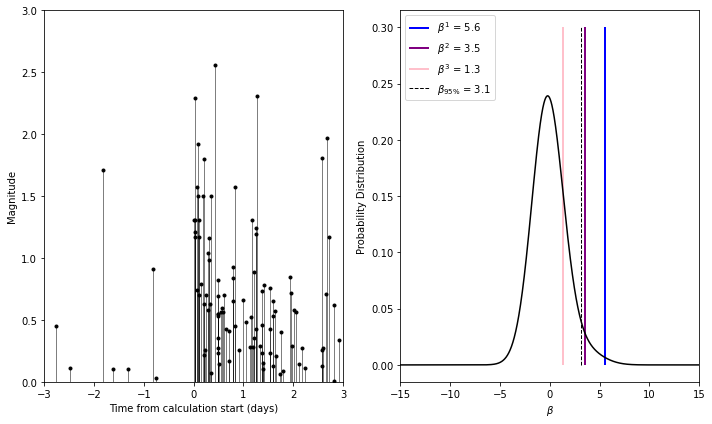

In [6]:
fig, ax = plt.subplots(1,2,figsize=(10,6))
plot_stems(ax[0], (grid_qtm_times_iwin-candidate_times[icand])/60/60/24,grid_qtm_mags_iwin, 'black')
ax[0].set_xlabel('Time from calculation start (days)')
ax[0].set_xlim(-3,3)
ax[0].set_ylim(0,3)
ax[0].set_ylabel('Magnitude')


ax[1].plot(np.arange(-15,15,.01),Beta_kde.evaluate(np.arange(-15,15,.01)),color='k')
ax[1].set_xlabel(r'$\beta$')
ax[1].set_xlim(-15,15)
ax[1].set_ylabel('Probability Distribution')
ax[1].vlines(beta_list[0],0,0.3,linewidth=2,label=r'$\beta^1$'+' = '+str(np.round(beta_list[0],1)),color='blue')
ax[1].vlines(beta_list[1],0,0.3,linewidth=2,label=r'$\beta^2$'+' = '+str(np.round(beta_list[1],1)),color='purple')
ax[1].vlines(beta_list[2],0,0.3,linewidth=2,label=r'$\beta^3$'+' = '+str(np.round(beta_list[2],1)),color='pink')
ax[1].vlines(Beta_95,0,0.3,linewidth=1,label=r'$\beta_{95\%}$'+' = '+str(np.round(Beta_95,1)),color='k',linestyle='--')
ax[1].legend(loc=2)
    
        
plt.tight_layout()
plt.show()